In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.neural_network import MLPClassifier

df = pd.read_csv("/content/sample_data/Daily_Water_Intake.csv")

print(df.head())
print(df.info())
print(df.describe())


   Age  Gender  Weight (kg)  Daily Water Intake (liters)  \
0   56    Male           96                         4.23   
1   60    Male          105                         3.95   
2   36    Male           68                         2.39   
3   19  Female           74                         3.13   
4   38    Male           77                         2.11   

  Physical Activity Level Weather Hydration Level  
0                Moderate     Hot            Good  
1                    High  Normal            Good  
2                Moderate    Cold            Good  
3                Moderate     Hot            Good  
4                     Low  Normal            Poor  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          30000 non-null  int64  
 1   Gender                       30000 non-n

2. Data Cleaning + Preprocessing

In [2]:
print(df.isnull().sum())

df = df.dropna()

label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


Age                            0
Gender                         0
Weight (kg)                    0
Daily Water Intake (liters)    0
Physical Activity Level        0
Weather                        0
Hydration Level                0
dtype: int64


3. Exploratory Data Analysis

<Figure size 640x480 with 0 Axes>

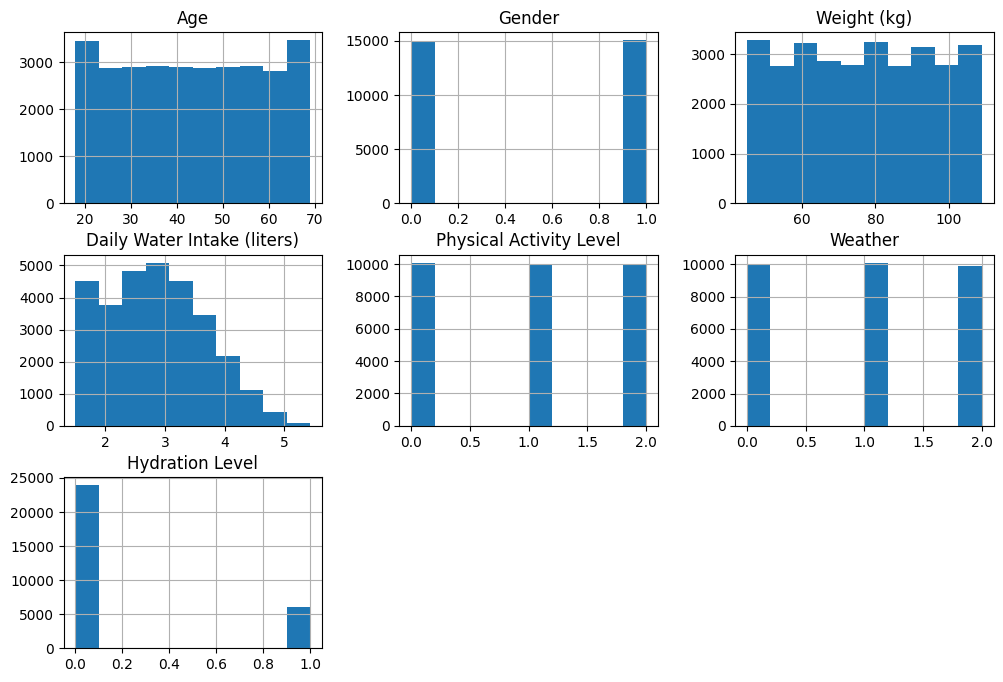

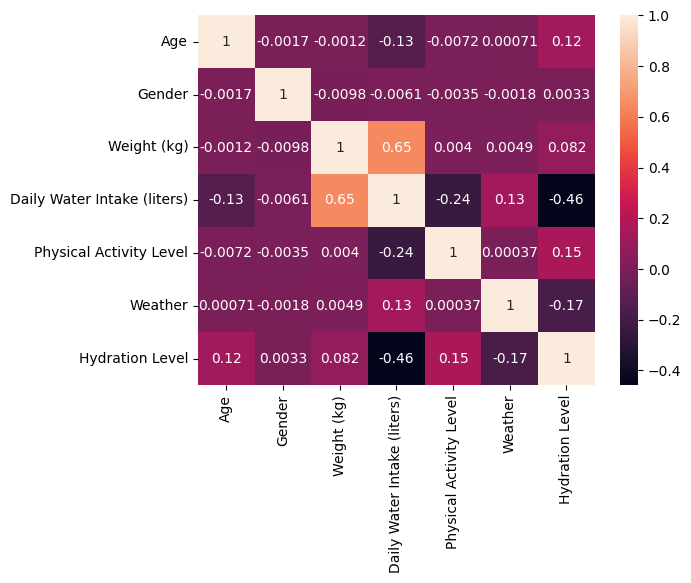

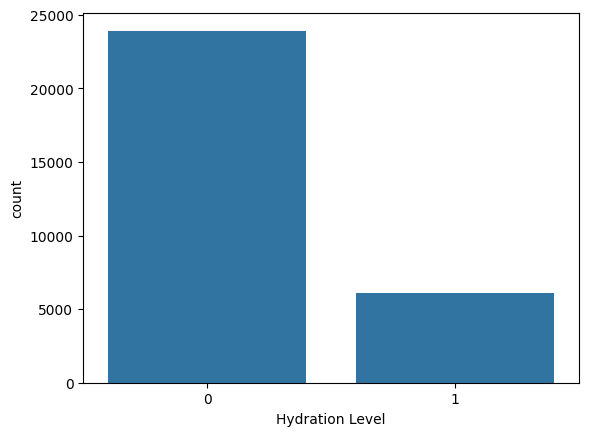

In [ ]:
plt.figure()
df.hist(figsize=(12,8))
plt.show()

target = df.columns[-1]

plt.figure()
sns.countplot(x=df[target])
plt.show()


4. Split Dataset

In [4]:
X = df.drop(columns=[target])
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


5. Neural Network Model (MLP)

In [5]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32),
                    activation='relu',
                    solver='adam',
                    max_iter=500)

mlp.fit(X_train, y_train)

y_pred_nn = mlp.predict(X_test)

print("Neural Network Performance")
print(classification_report(y_test, y_pred_nn))


Neural Network Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4788
           1       1.00      1.00      1.00      1212

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



6. Primary Models (Classical ML)

Logistic Regression

In [6]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


Decision Tree

In [7]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


Evaluation

In [8]:
def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted'),
        recall_score(y_true, y_pred, average='weighted'),
        f1_score(y_true, y_pred, average='weighted')
    ]

lr_metrics = evaluate(y_test, y_pred_lr)
dt_metrics = evaluate(y_test, y_pred_dt)

print("Logistic Regression:", lr_metrics)
print("Decision Tree:", dt_metrics)


Logistic Regression: [0.9976666666666667, 0.9976734693877551, 0.9976666666666667, 0.9976615925129478]
Decision Tree: [0.9981666666666666, 0.9981657429433703, 0.9981666666666666, 0.9981658178587428]


7. Hyperparameter Optimization

In [9]:
lr_params = {
    'C':[0.1,1,10],
    'solver':['lbfgs']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=500),
                       lr_params,
                       cv=5)

lr_grid.fit(X_train,y_train)

print("Best LR Params:", lr_grid.best_params_)
print("Best LR Score:", lr_grid.best_score_)


Best LR Params: {'C': 10, 'solver': 'lbfgs'}
Best LR Score: 0.9984166666666667


Decision Tree Grid

In [10]:
dt_params = {
    'max_depth':[3,5,10],
    'min_samples_split':[2,5,10]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(),
                       dt_params,
                       cv=5)

dt_grid.fit(X_train,y_train)

print("Best DT Params:", dt_grid.best_params_)
print("Best DT Score:", dt_grid.best_score_)


Best DT Params: {'max_depth': 10, 'min_samples_split': 2}
Best DT Score: 0.996875


8. Feature Selection|

In [12]:
selector = SelectKBest(score_func=f_classif, k=8)

X_new = selector.fit_transform(X_scaled,y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_new,y,test_size=0.2,random_state=42)

Selected Features: Index(['Age', 'Gender', 'Weight (kg)', 'Daily Water Intake (liters)',
       'Physical Activity Level', 'Weather'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=8 is greater than n_features=6. All the features will be returned.
  warnings.warn(


9. Final Models (Optimized + Selected Features)

In [14]:
final_lr = LogisticRegression(**lr_grid.best_params_,max_iter=500)
final_lr.fit(X_train_fs,y_train_fs)

final_dt = DecisionTreeClassifier(**dt_grid.best_params_)
final_dt.fit(X_train_fs,y_train_fs)

pred_lr = final_lr.predict(X_test_fs)
pred_dt = final_dt.predict(X_test_fs)

lr_final_metrics = evaluate(y_test_fs,pred_lr)
dt_final_metrics = evaluate(y_test_fs,pred_dt)

10. Comparison Table

In [15]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree"],
    "Accuracy":[lr_final_metrics[0],dt_final_metrics[0]],
    "Precision":[lr_final_metrics[1],dt_final_metrics[1]],
    "Recall":[lr_final_metrics[2],dt_final_metrics[2]],
    "F1":[lr_final_metrics[3],dt_final_metrics[3]]
})

print(comparison)


                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.998333   0.998337  0.998333  0.998331
1        Decision Tree  0.997333   0.997335  0.997333  0.997334
